# K-space exploration

Goal: explore a few random MRI samples, look at central slices in the main brain planes, normalize them, build k-space, and reconstruct the images back from k-space.


## 1. Preparation

In [1]:
import sys
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
from src.data_utils import (
    csv_path_to_local_path,
    load_metadata,
    load_volume,
    min_max_normalize,
    select_central_slice,
)
from src.general_utils import brain_planes, csvs, prepare_environment
from src.k_space_utils import image_to_kspace, kspace_log_magnitude, kspace_to_image

HPC = False

prepare_environment(hpc=HPC)

RANDOM_SEED = 1972
N_RANDOM_IMAGES = 3

np.random.seed(RANDOM_SEED)

Data path: C:\mri_dataset\brain_age


## 2. Load a few random images

In [2]:
train_df = load_metadata(csvs['train'])
print(f'Train rows: {len(train_df)}')
display(train_df.head(3))

Train rows: 4233


,Subject,ProjName,Age,filePath
0,CorrBMB_3013,Corr,26.06,/gpfs0/tamyr/projects/data/brain_age/npy/CorrB...
1,Sub0119_Ses1,GSP,23.00,/gpfs0/tamyr/projects/data/brain_age/npy/Sub01...
2,sub87089,Beijing_Zang,24.00,/gpfs0/tamyr/projects/data/brain_age/npy/sub87...


In [3]:
max_trials = min(len(train_df), max(30, 10 * N_RANDOM_IMAGES))
candidate_indices = np.random.permutation(len(train_df))[:max_trials]

samples = []
for idx in candidate_indices:
    row = train_df.iloc[idx]
    csv_path = row['filePath']
    local_path = Path(csv_path_to_local_path(csv_path))
    volume = load_volume(local_path)
    if volume is None:
        continue
    samples.append({
        'row_index': int(idx),
        'csv_path': csv_path,
        'local_path': str(local_path),
        'volume': volume,
    })
    if len(samples) == N_RANDOM_IMAGES:
        break

print(f'Loaded {len(samples)} / {N_RANDOM_IMAGES} requested random volumes')
for i, sample in enumerate(samples, start=1):
    print(f"{i}. row={sample['row_index']} shape={sample['volume'].shape} path={sample['local_path']}")



Loaded 3 / 3 requested random volumes
1. row=2483 shape=(90, 120, 99) path=selected_npy\NDARTT272WT5.npy
2. row=473 shape=(90, 120, 99) path=selected_npy\CorrIBATRT_27237.npy
3. row=1006 shape=(90, 120, 99) path=selected_npy\NDARKL327VRH.npy


## 3. Per plane: normalize, create k-space, reconstruct

In [13]:
def build_plane_views(volume: np.ndarray, axis: int) -> dict:
    slice_index, original_slice = select_central_slice(volume, axis)
    normalized_slice = min_max_normalize(original_slice)
    k_space = image_to_kspace(normalized_slice)
    reconstructed = np.abs(kspace_to_image(k_space))
    k_space_vis = kspace_log_magnitude(k_space)
    max_error = np.max(np.abs(reconstructed - normalized_slice))

    return {
        'slice_index': slice_index,
        'original': original_slice,
        'normalized': normalized_slice,
        'k_space_vis': k_space_vis,
        'reconstructed': reconstructed,
        'max_error': max_error,
    }
def show_four_panel(view_data: dict, sample_num: int, plane_name: str) -> None:
    fig, axes = plt.subplots(1, 4, figsize=(16, 4))

    axes[0].imshow(view_data['original'], cmap='gray')
    axes[0].set_title('Original')

    axes[1].imshow(view_data['normalized'], cmap='gray')
    axes[1].set_title('Normalized')

    axes[2].imshow(view_data['k_space_vis'], cmap='magma')
    axes[2].set_title('K-space (log magnitude)')

    axes[3].imshow(view_data['reconstructed'], cmap='gray')
    axes[3].set_title('Reconstructed from K-space')

    for ax in axes:
        ax.axis('off')

    fig.suptitle(f'Sample {sample_num} | Plane: {plane_name} | Center index: {view_data["slice_index"]} | Max error: {view_data["max_error"]:.16f}', fontsize=14)
    plt.tight_layout()
    plt.show()

## 4. Show the four images for each sample and plane

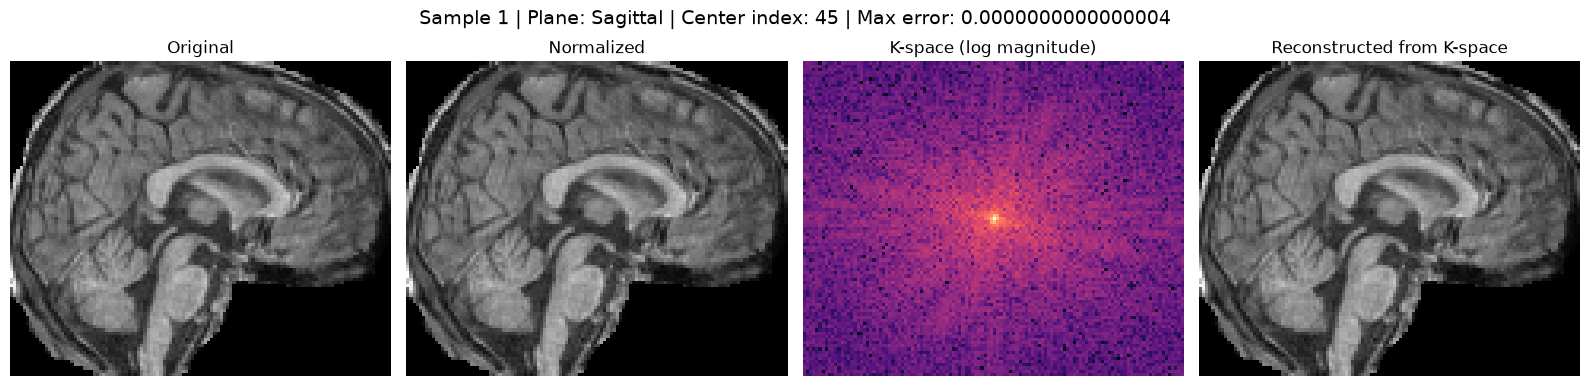

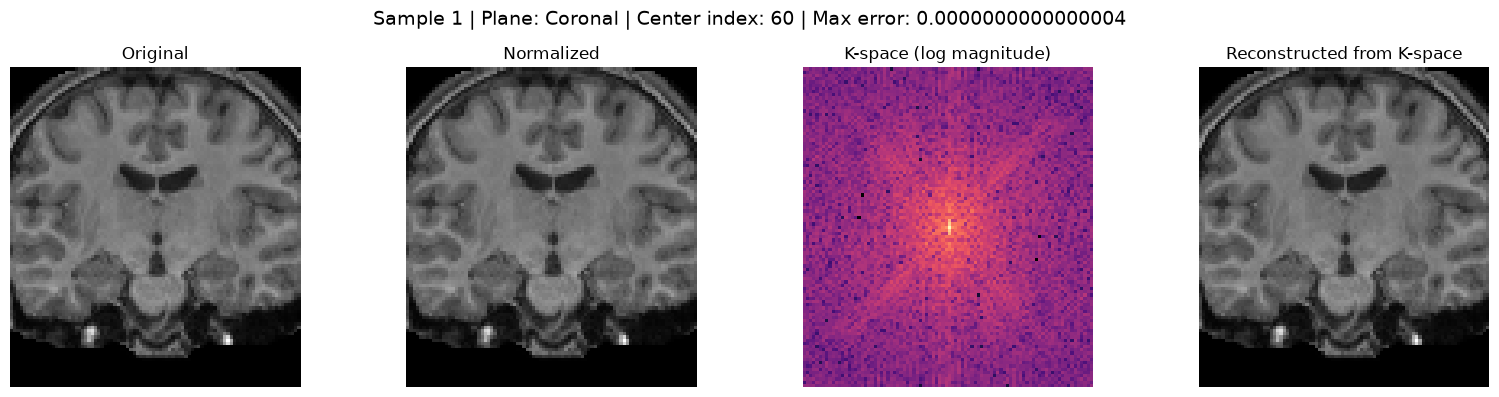

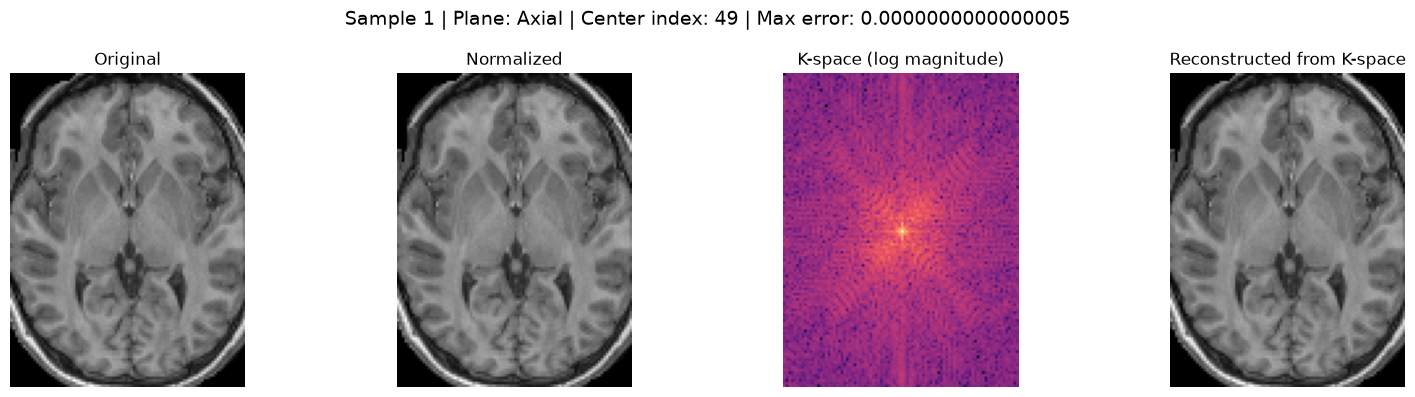

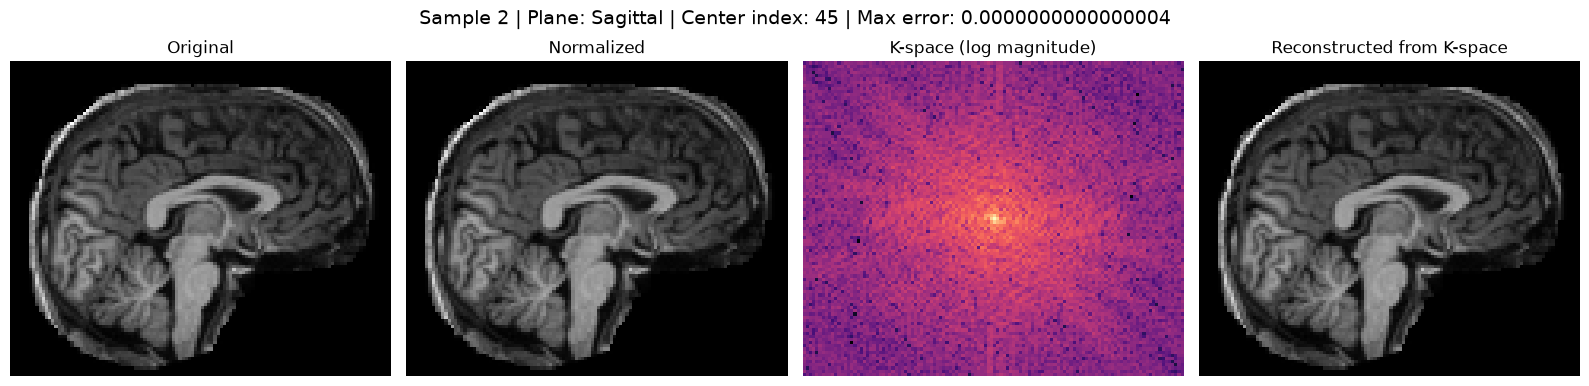

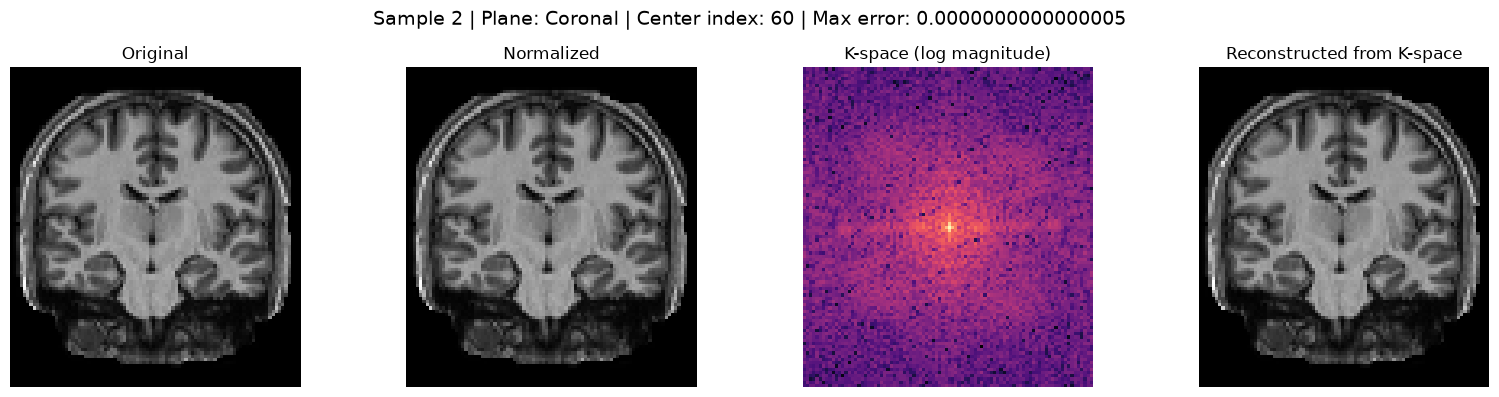

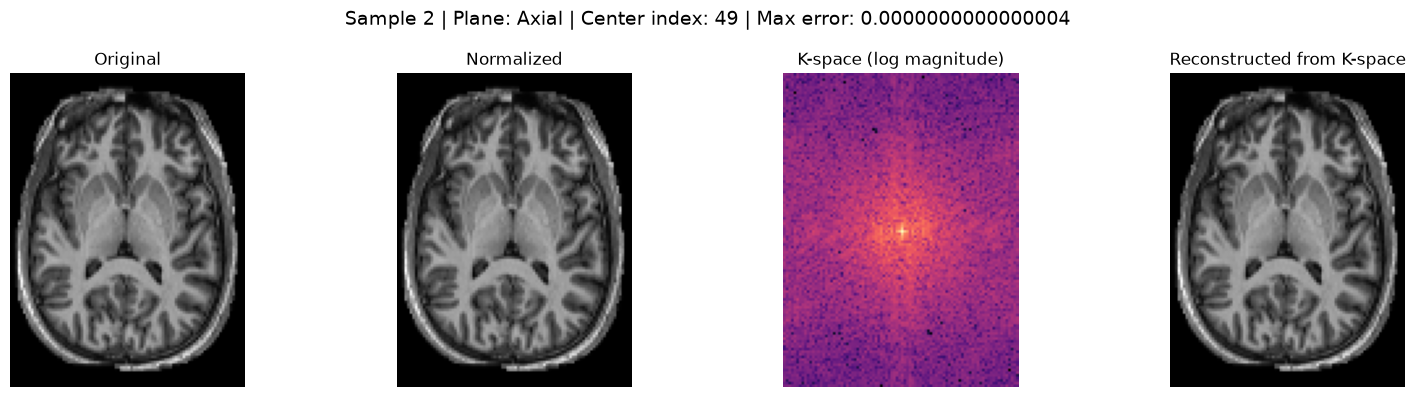

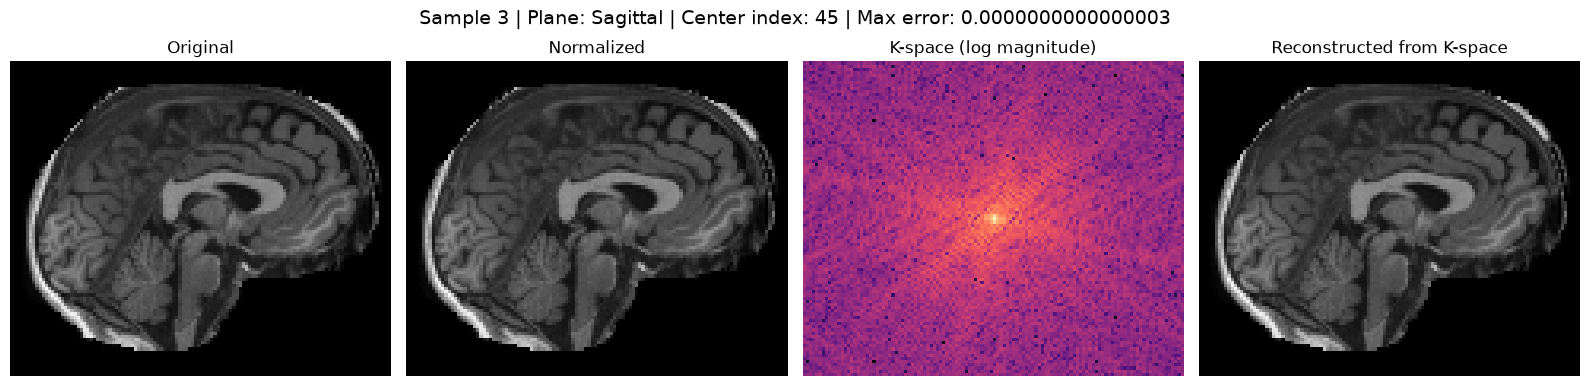

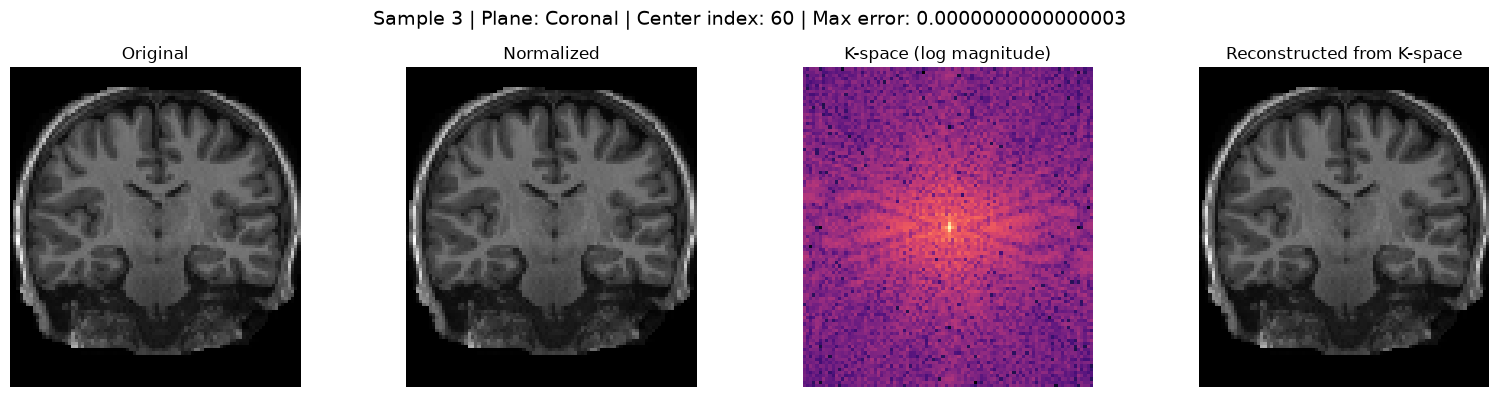

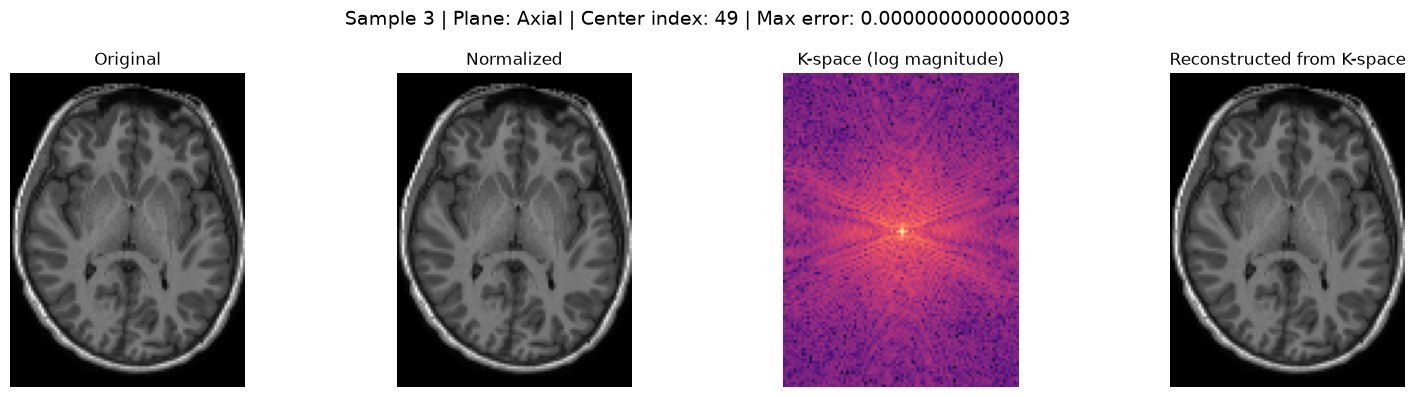

In [14]:
if not samples:
    print('No local random volumes were found. Check the data path and local files.')

for sample_num, sample in enumerate(samples, start=1):
    volume = sample['volume']
    for plane_name, axis in brain_planes.items():
        view_data = build_plane_views(volume, axis)
        show_four_panel(view_data, sample_num, plane_name)